In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [42]:
state_cases = pd.read_csv("us_county_confirmed_cases.csv")
state_deaths = pd.read_csv("us_county_confirmed_deaths.csv")

state_cases = state_cases.drop(columns=['COUNTY', 'NAME', 'POP70', 'HHD70', 'POP80', 'HHD80', 'POP90', 'HHD90',
       'POP00', 'HHD00', 'POP10', 'HHD10', 'countyFIPS', 'County Name', 'State', 'StateFIPS'])
state_deaths = state_deaths.drop(columns=['COUNTY', 'NAME', 'POP70', 'HHD70', 'POP80', 'HHD80', 'POP90', 'HHD90',
       'POP00', 'HHD00','POP10', 'HHD10', 'countyFIPS', 'County Name', 'State', 'StateFIPS'])

In [43]:
case_county = pd.DataFrame(state_cases)
len(case_county)
case_county['2022/9/1']

0       18125.0
1       64672.0
2        6757.0
3        7394.0
4       16597.0
         ...   
3138    12063.0
3139    11526.0
3140     6061.0
3141     2631.0
3142     1790.0
Name: 2022/9/1, Length: 3143, dtype: float64

### 1. how many 0 in that day, and we can drop

In [44]:
for col in list(case_county.columns):
    zero = len(case_county[case_county[col] == 0])
    pct_zero_c = zero/len(case_county)
    
    # need to define drop dates with how many 0
    if pct_zero_c > 0.2:
        print(col)
        case_county.drop(columns= col,inplace = True)

2020/1/22
2020/1/23
2020/1/24
2020/1/25
2020/1/26
2020/1/27
2020/1/28
2020/1/29
2020/1/30
2020/1/31
2020/2/1
2020/2/2
2020/2/3
2020/2/4
2020/2/5
2020/2/6
2020/2/7
2020/2/8
2020/2/9
2020/2/10
2020/2/11
2020/2/12
2020/2/13
2020/2/14
2020/2/15
2020/2/16
2020/2/17
2020/2/18
2020/2/19
2020/2/20
2020/2/21
2020/2/22
2020/2/23
2020/2/24
2020/2/25
2020/2/26
2020/2/27
2020/2/28
2020/2/29
2020/3/1
2020/3/2
2020/3/3
2020/3/4
2020/3/5
2020/3/6
2020/3/7
2020/3/8
2020/3/9
2020/3/10
2020/3/11
2020/3/12
2020/3/13
2020/3/14
2020/3/15
2020/3/16
2020/3/17
2020/3/18
2020/3/19
2020/3/20
2020/3/21
2020/3/22
2020/3/23
2020/3/24
2020/3/25
2020/3/26
2020/3/27
2020/3/28
2020/3/29
2020/3/30
2020/3/31
2020/4/1
2020/4/2
2020/4/3
2020/4/4
2020/4/5
2020/4/6


In [45]:
case_county

,2020/4/7,2020/4/8,2020/4/9,2020/4/10,2020/4/11,2020/4/12,2020/4/13,2020/4/14,2020/4/15,2020/4/16,...,2023/4/8,2023/4/9,2023/4/10,2023/4/11,2023/4/12,2023/4/13,2023/4/14,2023/4/15,2023/4/16,2023/4/17
0,12.0,12.0,17.0,17.0,19.0,19.0,19.0,23.0,25.0,25.0,...,19857.0,19857.0,19857.0,19857.0,19857.0,19873.0,19873.0,19873.0,19873.0,19873.0
1,42.0,49.0,59.0,59.0,66.0,71.0,78.0,87.0,98.0,102.0,...,70248.0,70248.0,70248.0,70248.0,70248.0,70299.0,70299.0,70299.0,70299.0,70299.0
2,3.0,3.0,7.0,9.0,10.0,10.0,10.0,11.0,13.0,14.0,...,7520.0,7520.0,7520.0,7520.0,7520.0,7553.0,7553.0,7553.0,7553.0,7553.0
3,8.0,9.0,11.0,11.0,13.0,16.0,17.0,17.0,19.0,23.0,...,8119.0,8119.0,8119.0,8119.0,8119.0,8122.0,8122.0,8122.0,8122.0,8122.0
4,10.0,10.0,11.0,12.0,12.0,13.0,15.0,16.0,17.0,18.0,...,18800.0,18800.0,18800.0,18800.0,18800.0,18817.0,18817.0,18817.0,18817.0,18817.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3138,6.0,6.0,6.0,7.0,7.0,7.0,9.0,9.0,10.0,10.0,...,12527.0,12527.0,12527.0,12527.0,12527.0,12527.0,12532.0,12532.0,12532.0,12532.0
3139,44.0,45.0,50.0,53.0,53.0,56.0,56.0,57.0,59.0,59.0,...,12156.0,12156.0,12156.0,12156.0,12156.0,12156.0,12161.0,12161.0,12161.0,12161.0
3140,3.0,3.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,...,6426.0,6426.0,6426.0,6426.0,6426.0,6426.0,6427.0,6427.0,6427.0,6427.0
3141,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,...,2702.0,2702.0,2702.0,2702.0,2702.0,2702.0,2702.0,2702.0,2702.0,2702.0


### 2. See the cases and deaths number throughout the nation to help figure out time period of Covid

In [46]:
all_cases = pd.DataFrame({'sum': state_cases.sum(axis=0)})
# get daily
all_cases['daily'] = (
    all_cases['sum'].transform(lambda s: s.sub(s.shift().fillna(0)).abs())
)
all_cases = all_cases.tail(-1)

all_deaths = pd.DataFrame({'sum': state_deaths.sum(axis=0)})
# get daily
all_deaths['daily'] = (
    all_deaths['sum'].transform(lambda s: s.sub(s.shift().fillna(0)).abs())
)
all_deaths = all_deaths.tail(-1)

<AxesSubplot: >

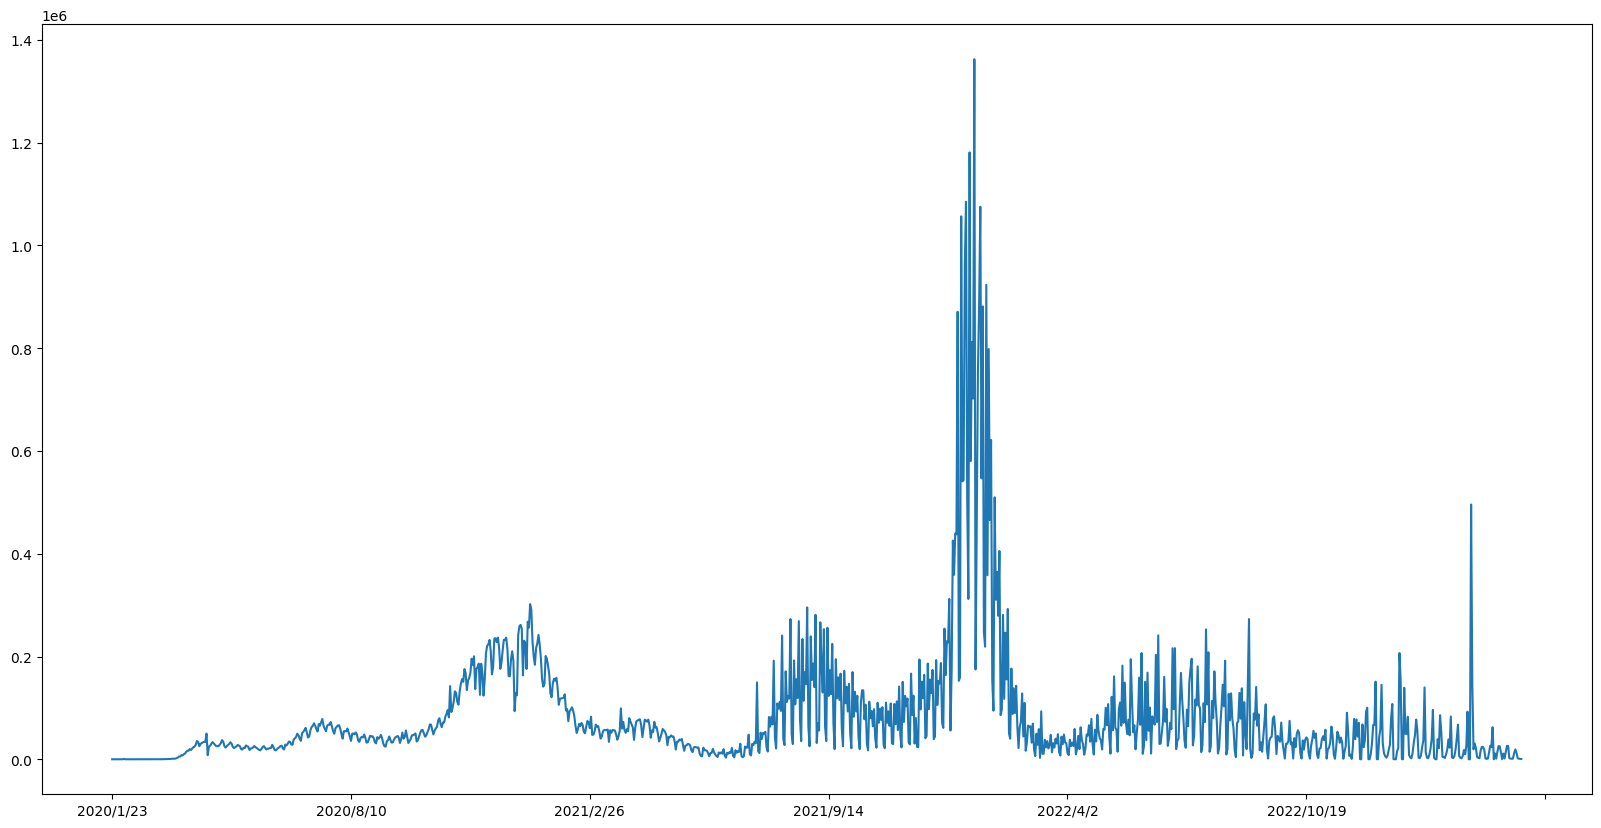

In [47]:
all_cases['daily'].plot(figsize=(20, 10))

<AxesSubplot: >

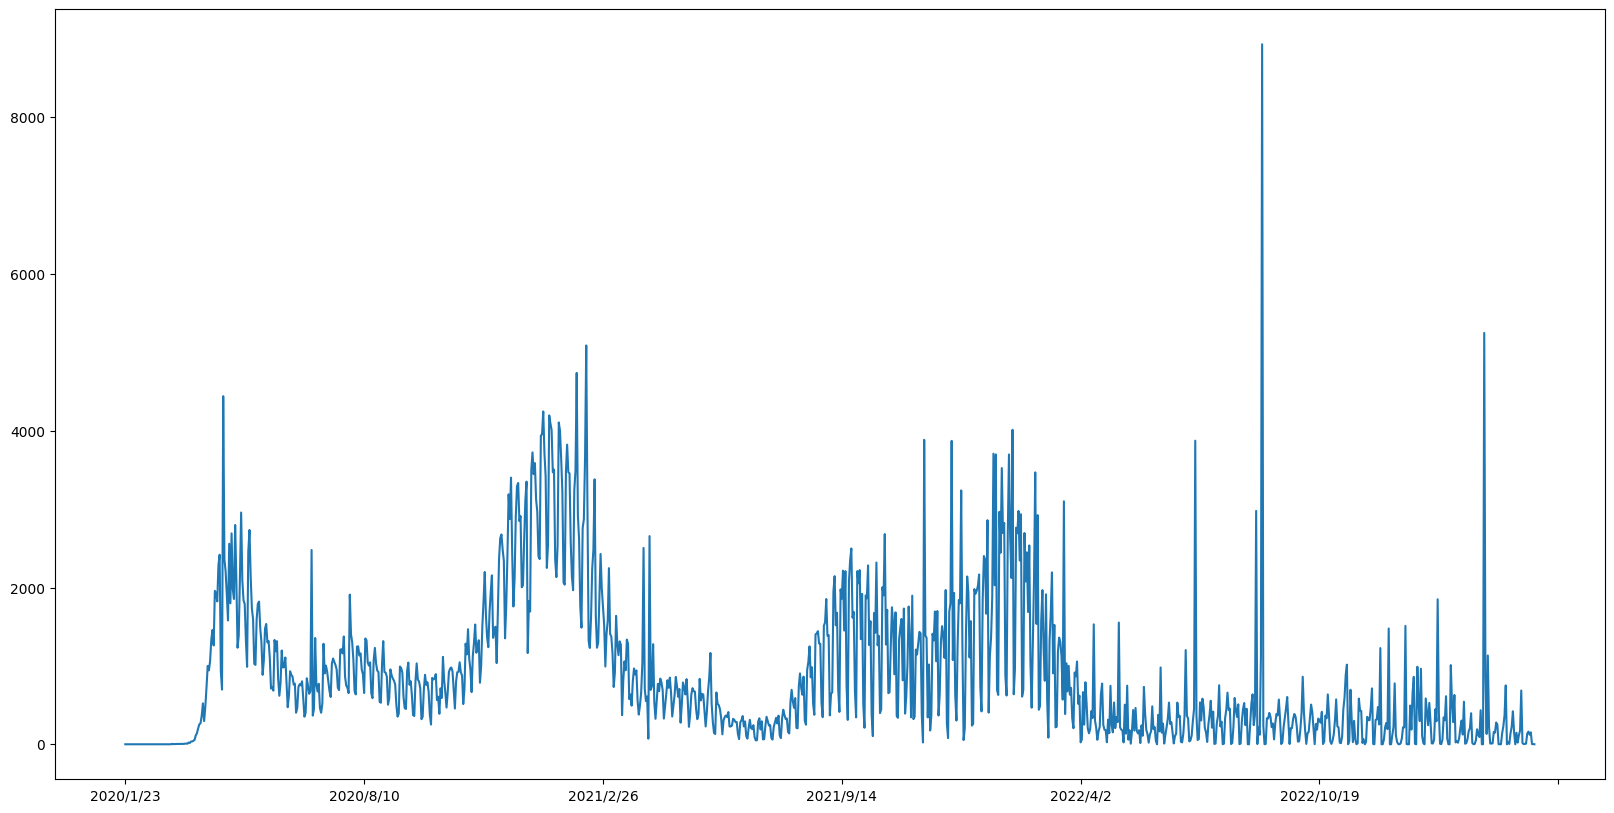

In [48]:
all_deaths['daily'].plot(figsize=(20, 10))

In [49]:
all_cases.head()

,sum,daily
2020/1/23,734.0,11.0
2020/1/24,741.0,7.0
2020/1/25,751.0,10.0
2020/1/26,759.0,8.0
2020/1/27,769.0,10.0


### 3. May seperate the covid into 3 period according to 
https://www.thelancet.com/journals/laninf/article/PIIS1473-3099(22)00320-6/fulltext
1. before around Jan 2021, the first COVID-19 vaccine wasn't delivered outside of a clinical trial setting
2. Jan 2021-Jan 2022, more than half population have received at least one dose of a COVID-19 vaccine
3. after Jan 2022

### Or
#### we use statistical methods and try to figure out different periods.

#### BTW: see the medians, might use date having median cases in one period I think

In [50]:
print(all_cases['daily'].idxmax())
all_cases.sort_values(by = 'daily',ascending = False).head(10)

2022/1/14


,sum,daily
2022/1/14,63514335.0,1362265.0
2022/1/10,60057935.0,1181015.0
2022/1/7,58055606.0,1085037.0
2022/1/19,66859028.0,1075290.0
2022/1/3,54926383.0,1056558.0
2022/1/6,56970569.0,959931.0
2022/1/24,69676589.0,923233.0
2022/1/18,65783738.0,887893.0
2022/1/21,68287066.0,881293.0
2021/12/31,53557811.0,870883.0


In [51]:
# the dataset is not normally distributed
import scipy.stats as stats
w, pvalue = stats.shapiro(all_cases.daily)
print(w, pvalue)

0.539780855178833 0.0


In [52]:
all_cases.index=pd.to_datetime(all_cases.index,format="%Y/%m/%d")
all_cases = all_cases.reset_index()
all_cases

,index,sum,daily
0,2020-01-23,734.0,11.0
1,2020-01-24,741.0,7.0
2,2020-01-25,751.0,10.0
3,2020-01-26,759.0,8.0
4,2020-01-27,769.0,10.0
...,...,...,...
1176,2023-04-13,96919577.0,12617.0
1177,2023-04-14,96921668.0,2091.0
1178,2023-04-15,96922761.0,1093.0
1179,2023-04-16,96923507.0,746.0


In [54]:
all_cases = all_cases.rename(columns = {'index':'date'}) 

In [55]:
all_cases

,date,sum,daily
0,2020-01-23,734.0,11.0
1,2020-01-24,741.0,7.0
2,2020-01-25,751.0,10.0
3,2020-01-26,759.0,8.0
4,2020-01-27,769.0,10.0
...,...,...,...
1176,2023-04-13,96919577.0,12617.0
1177,2023-04-14,96921668.0,2091.0
1178,2023-04-15,96922761.0,1093.0
1179,2023-04-16,96923507.0,746.0


In [66]:
from datetime import datetime

for row in all_cases['daily']:
    p1_df = all_cases[all_cases.date <=datetime(2021,4,6)]
    p1_df = p1_df[p1_df.date> datetime(2020,4,6)]
    p1_med = p1_df['daily'].median()
print(p1_med)
print('date around median1: ',p1_df.date[p1_df.daily[p1_df.daily>=p1_med].idxmin()])
print('date around median2: ',p1_df.date[p1_df.daily[p1_df.daily<p1_med].idxmax()])
print(p1_df[p1_df.date==datetime(2020,10,19)])
print(p1_df[p1_df.date==datetime(2020,7,26)])
p1_df

55789.0
date around median1:  2020-10-19 00:00:00
date around median2:  2020-07-26 00:00:00
          date        sum    daily
270 2020-10-19  8129306.0  55789.0
          date        sum    daily
185 2020-07-26  4275548.0  55038.0


,date,sum,daily
75,2020-04-07,400908.0,31654.0
76,2020-04-08,433861.0,32953.0
77,2020-04-09,467791.0,33930.0
78,2020-04-10,501312.0,33521.0
79,2020-04-11,551254.0,49942.0
...,...,...,...
435,2021-04-02,29991100.0,67674.0
436,2021-04-03,30053425.0,62325.0
437,2021-04-04,30091168.0,37743.0
438,2021-04-05,30152627.0,61459.0


In [69]:
for row in all_cases['daily']:
    p2_df = all_cases[all_cases.date <=datetime(2022,4,6)]
    p2_df = p2_df[p2_df.date> datetime(2021,4,6)]
    p2_med = p2_df['daily'].median()
print(p2_med)
print('date around median1: ',p2_df.date[p2_df.daily[p2_df.daily>=p2_med].idxmin()])
print('date around median2: ',p2_df.date[p2_df.daily[p2_df.daily<p2_med].idxmax()])
print(p2_df[p2_df.date==datetime(2022,2,19)])
print(p2_df[p2_df.date==datetime(2021,9,11)])
p2_df

64065.0
date around median1:  2022-02-19 00:00:00
date around median2:  2021-09-11 00:00:00
          date         sum    daily
758 2022-02-19  76103763.0  64065.0
          date         sum    daily
597 2021-09-11  39926429.0  63764.0


,date,sum,daily
440,2021-04-07,30302055.0,75353.0
441,2021-04-08,30379102.0,77047.0
442,2021-04-09,30456897.0,77795.0
443,2021-04-10,30522783.0,65886.0
444,2021-04-11,30565938.0,43155.0
...,...,...,...
800,2022-04-02,77759958.0,12134.0
801,2022-04-03,77768165.0,8207.0
802,2022-04-04,77806091.0,37926.0
803,2022-04-05,77831855.0,25764.0


In [73]:
for row in all_cases['daily']:
    p3_df = all_cases[all_cases.date <=datetime(2023,4,6)]
    p3_df = p3_df[p3_df.date> datetime(2022,4,6)]
    p3_med = p3_df['daily'].median()
print(p3_med)
print('date around median1: ',p3_df.date[p3_df.daily[p3_df.daily>=p3_med].idxmin()])
print('date around median2: ',p3_df.date[p3_df.daily[p3_df.daily<p3_med].idxmax()])
print(p3_df[p3_df.date==datetime(2023,2,15)])
print(p3_df[p3_df.date==datetime(2022,4,14)])
p3_df

38574.0
date around median1:  2023-02-15 00:00:00
date around median2:  2022-04-14 00:00:00
           date         sum    daily
1119 2023-02-15  95356049.0  38574.0
          date         sum    daily
812 2022-04-14  78144411.0  38246.0


,date,sum,daily
805,2022-04-07,77889731.0,25791.0
806,2022-04-08,77948648.0,58917.0
807,2022-04-09,77958373.0,9725.0
808,2022-04-10,77978745.0,20372.0
809,2022-04-11,78024169.0,45424.0
...,...,...,...
1165,2023-04-02,96803298.0,11107.0
1166,2023-04-03,96804931.0,1633.0
1167,2023-04-04,96818393.0,13462.0
1168,2023-04-05,96844443.0,26050.0


### ANOVA test, to see if there is significant difference between three groups - cases
I thought if there is some significant differences between groups, our methods would be more valid.
- seems fail to prove

In [87]:
# pick rows for periods to make the dataset balanced
sample_num = min(len(p1_df),len(p2_df),len(p3_df))

p1_df_sample = p1_df.sample(n=sample_num).reset_index(drop = True)
p2_df_sample = p2_df.sample(n=sample_num).reset_index(drop = True)
p3_df_sample = p3_df.sample(n=sample_num).reset_index(drop = True)
p1_df_sample.drop(columns=['sum','date'],inplace = True)
p2_df_sample.drop(columns=['sum','date'],inplace = True)
p3_df_sample.drop(columns=['sum','date'],inplace = True)

# p1_df_sample = p1_df.reset_index().drop(columns=['sum','index'])
# p2_df_sample = p2_df.reset_index().drop(columns=['sum','index'])
# p3_df_sample = p3_df.reset_index().drop(columns=['sum','index'])


In [88]:
p1_df_sample.rename(columns={'daily':'p1d'},inplace = True)
p2_df_sample.rename(columns={'daily':'p2d'},inplace = True)
p3_df_sample.rename(columns={'daily':'p3d'},inplace = True)

In [89]:
p1_df_sample

,p1d
0,183876.0
1,50300.0
2,141292.0
3,31740.0
4,24480.0
...,...
360,28146.0
361,24834.0
362,95811.0
363,49092.0


In [90]:
df_anova = pd.concat([p1_df_sample,p2_df_sample,p3_df_sample],axis=1) 
df_anova

,p1d,p2d,p3d
0,183876.0,311925.0,49807.0
1,50300.0,14106.0,60559.0
2,141292.0,194710.0,100555.0
3,31740.0,75353.0,272976.0
4,24480.0,7250.0,26106.0
...,...,...,...
360,28146.0,152519.0,11091.0
361,24834.0,77135.0,206850.0
362,95811.0,21065.0,36759.0
363,49092.0,93010.0,48136.0


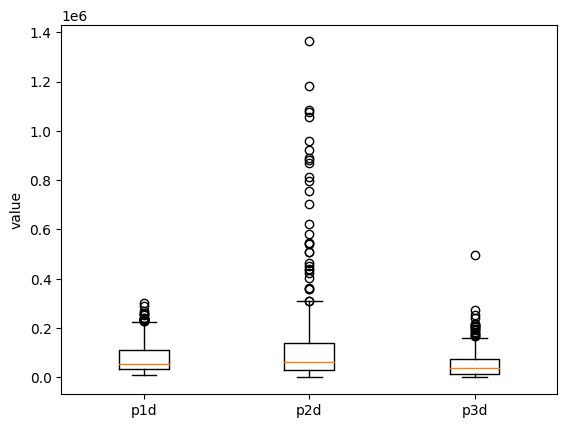

In [91]:
# reshape the d dataframe suitable for statsmodels package 
df_melt = pd.melt(df_anova.reset_index(), id_vars=['index'], value_vars=['p1d', 'p2d', 'p3d'])
# replace column names
df_melt.columns = ['index', 'periods', 'value']

# generate a boxplot to see the data distribution by treatments. Using boxplot, we can 
# easily detect the differences between different treatments
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1)
ax.boxplot([df_anova.p1d, df_anova.p2d, df_anova.p3d])
# ax.boxplot([p1_df_sample.p1d, p2_df_sample.p2d, p3_df_sample.p3d])
ax.set_xticklabels(["p1d", "p2d", "p3d"]) 
ax.set_ylabel("value") 
plt.show()

In [92]:
import scipy.stats as stats
# stats f_oneway functions takes the groups as input and returns ANOVA F and p value
fvalue, pvalue = stats.f_oneway(df_anova['p1d'], df_anova['p2d'], df_anova['p3d'])
# fvalue, pvalue = stats.f_oneway(p1_df_sample.p1d, p2_df_sample.p2d, p3_df_sample.p3d)
print(fvalue, pvalue)
# 9.619937034375106 7.255921847755048e-05

# get ANOVA table as R like output
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Ordinary Least Squares (OLS) model
model = ols('value ~ C(periods)', data=df_melt).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
anova_table

34.72548955944292 2.3937436957637048e-15


,sum_sq,df,F,PR(>F)
C(periods),1.090453e+12,2.0,34.72549,2.393744e-15
Residual,1.714555e+13,1092.0,NaN,NaN


### It shows significantly different in terms of cases

In [93]:
# ANOVA posthoc_tukey
from scipy.stats import tukey_hsd
res = tukey_hsd(df_anova.p1d, df_anova.p2d, df_anova.p3d)
print(res)

Tukey's HSD Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1) -48778.416     0.000-70546.927-27009.906
 (0 - 2)  27541.652     0.009  5773.141 49310.163
 (1 - 0)  48778.416     0.000 27009.906 70546.927
 (1 - 2)  76320.068     0.000 54551.558 98088.579
 (2 - 0) -27541.652     0.009-49310.163 -5773.141
 (2 - 1) -76320.068     0.000-98088.579-54551.558



### Test ANOVA assumptions
- is not normally distributed
- Test Failed
- results is not convincing

In [94]:
import scipy.stats as stats
w, pvalue = stats.shapiro(model.resid)
print(w, pvalue)

0.609900712966919 3.6433760072445244e-44


In [95]:
import scipy.stats as stats
w, pvalue = stats.shapiro(p1_df_sample.p1d)
print('p1',w, pvalue)
w, pvalue = stats.shapiro(p2_df_sample.p2d)
print('p2',w, pvalue)
w, pvalue = stats.shapiro(p3_df_sample.p3d)
print('p3',w, pvalue)

p1 0.8097110390663147 2.0516386249742285e-20
p2 0.5813888311386108 1.056724177081871e-28
p3 0.7987845540046692 5.95011734514385e-21


In [96]:
import scipy.stats as stats
w, pvalue = stats.bartlett(df_anova.p1d, df_anova.p2d, df_anova.p3d)
print(w, pvalue)

710.610586115945 4.930282832599119e-155


0          11.0
1           7.0
2          10.0
3           8.0
4          10.0
         ...   
1176    12617.0
1177     2091.0
1178     1093.0
1179      746.0
1180      544.0
Name: daily, Length: 1181, dtype: float64

### 4. death rate

In [108]:
all_cases = pd.DataFrame({'sum': state_cases.sum(axis=0)})
# get daily
all_cases['daily'] = (
    all_cases['sum'].transform(lambda s: s.sub(s.shift().fillna(0)).abs())
)
all_cases = all_cases.tail(-1)

all_deaths = pd.DataFrame({'sum': state_deaths.sum(axis=0)})
# get daily
all_deaths['daily'] = (
    all_deaths['sum'].transform(lambda s: s.sub(s.shift().fillna(0)).abs())
)
all_deaths = all_deaths.tail(-1)

In [109]:
all_deaths['rate'] = all_deaths['sum'] / all_cases['sum']

<AxesSubplot: >

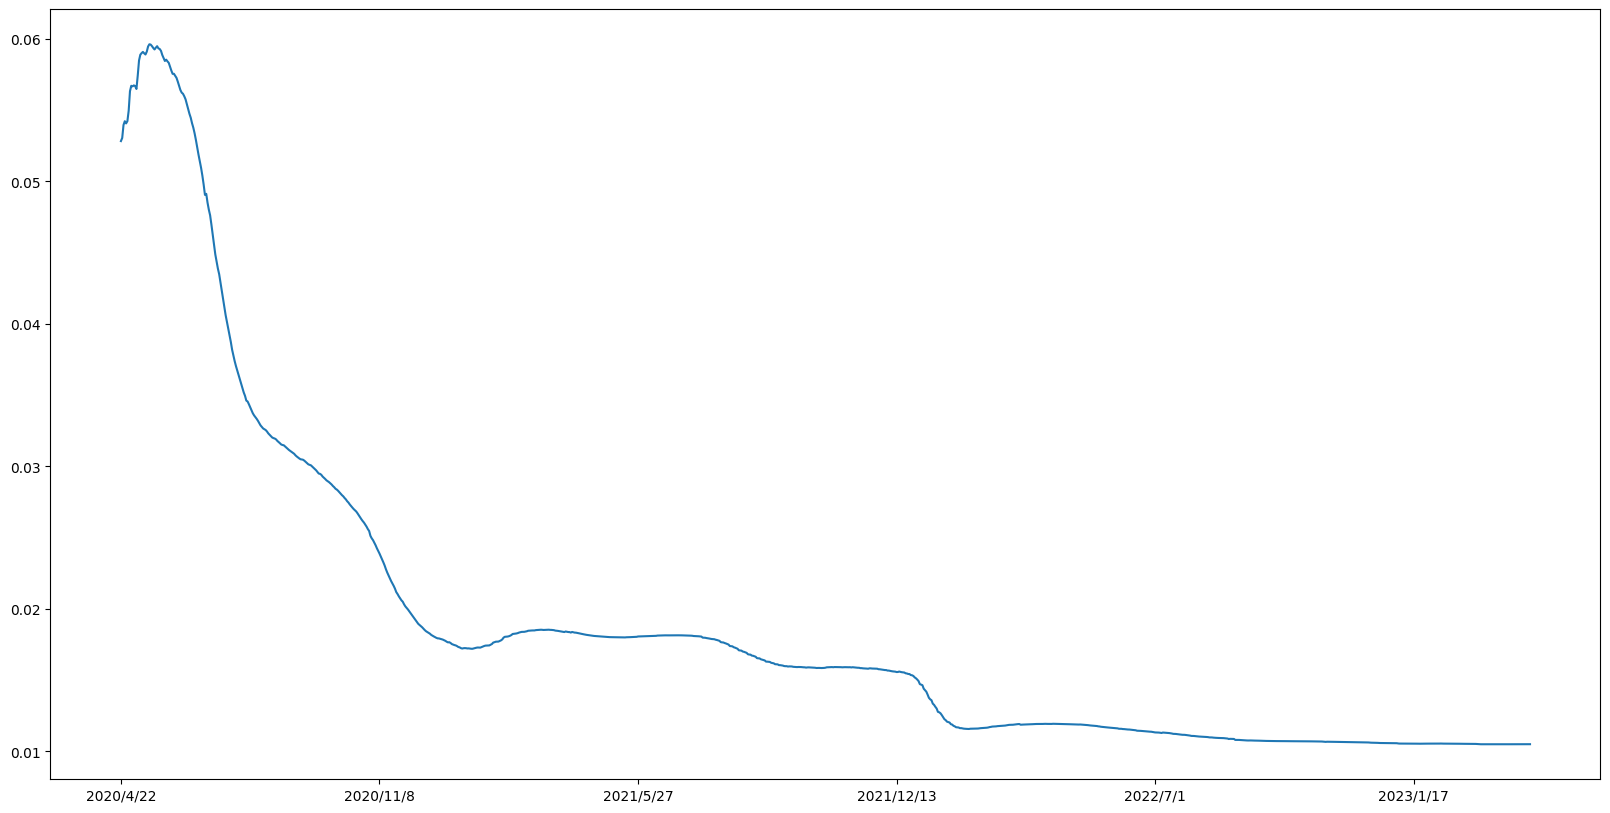

In [110]:
all_deaths['rate'][90:].plot(figsize=(20, 10))

In [106]:
all_deaths.rate.isnull().sum()

11